<h1>Section 1: File Integrity Checker</h1>

In [ ]:
import os 
import hashlib
import csv
import time
folder_path = "samples"
# Folder contains samples that will be hashed
# opens csv file to store the results 
with open("results.csv", 'w', newline='')as file:
    writer = csv.writer(file)
    # write the header row in the CSV file
    writer.writerow(["filename", "timestamp", "Hash"])
    # loop through every file in the target folder
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
    # open file in binary mode and it reads the content
        with open(file_path, "rb") as f:
            file_content = f.read()
            # computes the hash of the file content
            hash_file = hashlib.sha256(file_content).hexdigest()
        # generates a timestamp for when the file was processed
        timestamp = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
        # writes the filename, timestamp and hash into the csv
        writer.writerow([filename, timestamp, hash_file])
print("successfully written into csv!")   

successfully written into csv!



 <h1> Section 2: Detecting Suspicious File Changes </h1>


In [ ]:
import os
import hashlib
import csv
import time

folder_path = "samples"
csv_file = "results.csv"

# Reads a file a binary mode and return it in SHA-256 hash
def calculate_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()
    
# loads previous sabed hashes from the csv file
def read_old_hashes():
    old_hashes = {}
    with open(csv_file, 'r', newline='') as file:
        reader = csv.DictReader(file)
        for row in reader:
            old_hashes[row["filename"]] = row["Hash"]
    return old_hashes

# Computes new hashes for all files, compares them with the stores hashes and than detects the changes
def scan_and_compare():
    # Loads hashes from last scan
    old_hashes = read_old_hashes()
    new_hashes = {}
# computes fresh hases for current files
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):
            new_hash = calculate_hash(file_path)
            new_hashes[filename] = new_hash

    print(" comparing new hashes...\n")
    # checks for modified files
    for filename, new_hash in new_hashes.items():
        if filename in old_hashes:
            old_hash = old_hashes[filename]
            if new_hash != old_hash:
                print(f" {filename} has been modified")
        else:
            # Files appears in new scan but not old
            print(f"{filename} is new.")
# check for removed files
    for filename in old_hashes:
        if filename not in new_hashes:
            print(f"{filename} was removed.")

    print("\n Scan complete!")

scan_and_compare()


 comparing new hashes...

a.pdf is new.
week 1.pdf was removed.

 Scan complete!



  <h1> Section 3: Signature-Based Malware Detection  </h1>


In [ ]:
import os
import re 
# common list of suspicious code patterns
SIGNATURES = [r"eval\(", r"base64\.b64decode", r"socket\.connect", r"exec\(", r"import os"]

# folder containing files to scan for suspicious patterns
folder_path = "maleware"

# This function goes hrough each file, reads the content safely, checks for presence
# of any suspicious signatures, print warning when matches found.
def scanformaleware():
    for filename in os.listdir(folder_path):    
        path = os.path.join(folder_path, filename)

        # opens the file as a text
        with open(path, "r", errors = "ignore") as file:
            code = file.read()

            # searches for malware signature
            for pattern in SIGNATURES:
                if re.search(pattern, code):
                    print(f"found match in: {path} (pattern: {pattern})")

scanformaleware()


found match in: maleware\malicious.py (pattern: eval\()
found match in: maleware\malicious.py (pattern: import os)
found match in: maleware\malicious1.py (pattern: base64\.b64decode)




   <h1>Section 4: Worm Propagation Simulation  </h1>


Step 1: 1 infected
Step 2: 2 infected
Step 3: 3 infected
Step 4: 4 infected
Step 5: 5 infected
Step 6: 5 infected
Step 7: 7 infected
Step 8: 11 infected
Step 9: 12 infected
Step 10: 16 infected


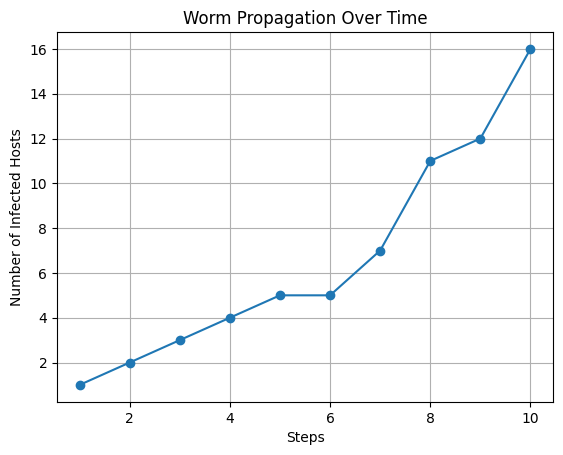

In [ ]:
import random
import matplotlib.pyplot as plt


hosts = 100
infected = {0}
steps = 10
tries = 3 
success = 0.1

# List to track how many hosts are infected each step
infected_counts = []

for step in range(1, steps+1):
    # Tracks hosts infected during this step
    newly_infected = set()

# Each infected host tries to infect others
    for host in infected:
        for _ in range(tries):
            target = random.randint(0, hosts-1)

            # infection succeds only if target is not already infected,
            # random chance is greater than success probability.
            if target not in infected and random.random() < success:
                newly_infected.add(target)

# Add the new infections to the infected set
    infected.update(newly_infected)
    # Record infection count
    infected_counts.append(len(infected))
    print(f"Step {step}: {len(infected)} infected")

# Stop simulation early if entire population is infected
    if len(infected) >= hosts:
        print("Hosts are all infected")
        break

# Results are than plotted
plt.plot(range(1, len(infected_counts) + 1), infected_counts, marker='o')
plt.title("Worm Propagation Over Time")
plt.xlabel("Steps")
plt.ylabel("Number of Infected Hosts")
plt.grid(True)
plt.show()


<h1>Section 5: Countermeasure Design Challenge</h1>

Step 1: 1 infected
Step 2: 1 infected
Step 3: 2 infected
Step 4: 2 infected
Step 5: 2 infected
Step 6: 3 infected
Step 7: 4 infected
Step 8: 7 infected
Step 9: 8 infected
 Cleanup triggered at step 10: 11 hosts cleaned.
Step 10: 0 infected
 All hosts cleaned. Simulation continues.

Step 11: 0 infected
 All hosts cleaned. Simulation continues.

Step 12: 0 infected
 All hosts cleaned. Simulation continues.

Step 13: 0 infected
 All hosts cleaned. Simulation continues.

Step 14: 0 infected
 All hosts cleaned. Simulation continues.

Step 15: 0 infected
 All hosts cleaned. Simulation continues.



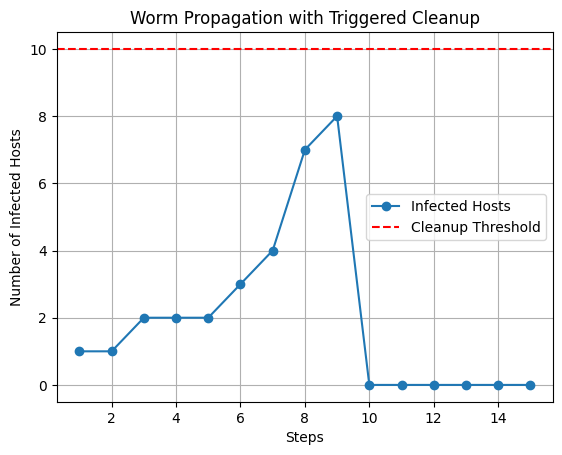

In [4]:
import random
import matplotlib.pyplot as plt

hosts = 200
infected = {0}   
steps = 15
tries = 3
success = 0.1
cleanup_threshold = 10 
infected_counts = []

for step in range(1, steps + 1):
    # stores hosts infected during this time step

    newly_infected = set() 
# each infected host attempts to infect 
    for host in infected:
        for _ in range(tries):
            target = random.randint(0, hosts - 1)

            # infected only happens if target is not infected, random 
            # chance less than success probaility.
            if target not in infected and random.random() < success:
                newly_infected.add(target)
# add the new infections to the infected list
    infected.update(newly_infected)

# trigger cleanup when the infection reaches the threshold
    if len(infected) >= cleanup_threshold:
        print(f" Cleanup triggered at step {step}: {len(infected)} hosts cleaned.")
        infected.clear()  
#         the clear function removes all infections
# records infection count after cleanup
    infected_counts.append(len(infected))
    print(f"Step {step}: {len(infected)} infected")

    if len(infected) == 0:
        print(" All hosts cleaned. Simulation continues.\n")
# plots results
plt.plot(range(1, len(infected_counts) + 1), infected_counts, marker='o', label='Infected Hosts')
plt.axhline(y=cleanup_threshold, color='r', linestyle='--', label='Cleanup Threshold')
plt.title("Worm Propagation with Triggered Cleanup")
plt.xlabel("Steps")
plt.ylabel("Number of Infected Hosts")
plt.legend()
plt.grid(True)
plt.show()


<h1>(Challenge)Section 6: Countermeasure Design Against Brute Forcer</h1>

In [9]:
import subprocess
import time

# this states my target which is a loopback address so all the pings stay on my own machine
TARGET = "127.0.0.1"     
#maximum number of pings before rating is apploed
MAX_ATTEMPTS = 10       
#duration until the system locks after too many requests
RATE_LIMIT = 5          

# Sends an ICMP ping to the target system using the ping command and returns
# true is the target responds

def ping_once(target):
    try:
        #n-1 means send exactly one ping packet
        result = subprocess.run(["ping", "-n", "1", target], 
                                #gets the output
                                stdout=subprocess.PIPE,
                                #gets the errors
                                stderr=subprocess.PIPE)
        #if return code is zero than ping = successful
        return result.returncode == 0
    except Exception as e:
        print("ping error:", e)
        return False

#this is where the brute forcer begins and the attempts is the counter for how many pings have been sent
# and the time of the attack is being recorded
attempts = 0
start_time = time.time()

print("Starting brute forcer..\n")
# it keeps looping until the maximum attempts is than reached
while attempts < MAX_ATTEMPTS:
    attempts += 1
    print(f"Attempt {attempts}: Pinging {TARGET}...")
# it than sends the ping and gets success or fail
    success = ping_once(TARGET)

    if success:
        print("Ping successful\n")
    else:
        print("Ping failed\n")

    time.sleep(0.5) #adding a small delay so it looks more realistic

#this section than reports the results 
end_time = time.time()
print(f"Brute force complete in {end_time - start_time:.2f}s\n")

print(f"too many requests! rate-limiting for {RATE_LIMIT}s\n")
time.sleep(RATE_LIMIT)

print("system has been unlocked")




Starting brute forcer..

Attempt 1: Pinging 127.0.0.1...
Ping successful

Attempt 2: Pinging 127.0.0.1...
Ping successful

Attempt 3: Pinging 127.0.0.1...
Ping successful

Attempt 4: Pinging 127.0.0.1...
Ping successful

Attempt 5: Pinging 127.0.0.1...
Ping successful

Attempt 6: Pinging 127.0.0.1...
Ping successful

Attempt 7: Pinging 127.0.0.1...
Ping successful

Attempt 8: Pinging 127.0.0.1...
Ping successful

Attempt 9: Pinging 127.0.0.1...
Ping successful

Attempt 10: Pinging 127.0.0.1...
Ping successful

Brute force complete in 5.12s

too many requests! rate-limiting for 5s

system has been unlocked
